Condition Number for Degree 4 Polynomial Matrix: 3.31e+14
Condition Number for Degree 1 Polynomial Matrix: 3.61e+03
Linear Trend Slope (Excluding COVID): 0.0186


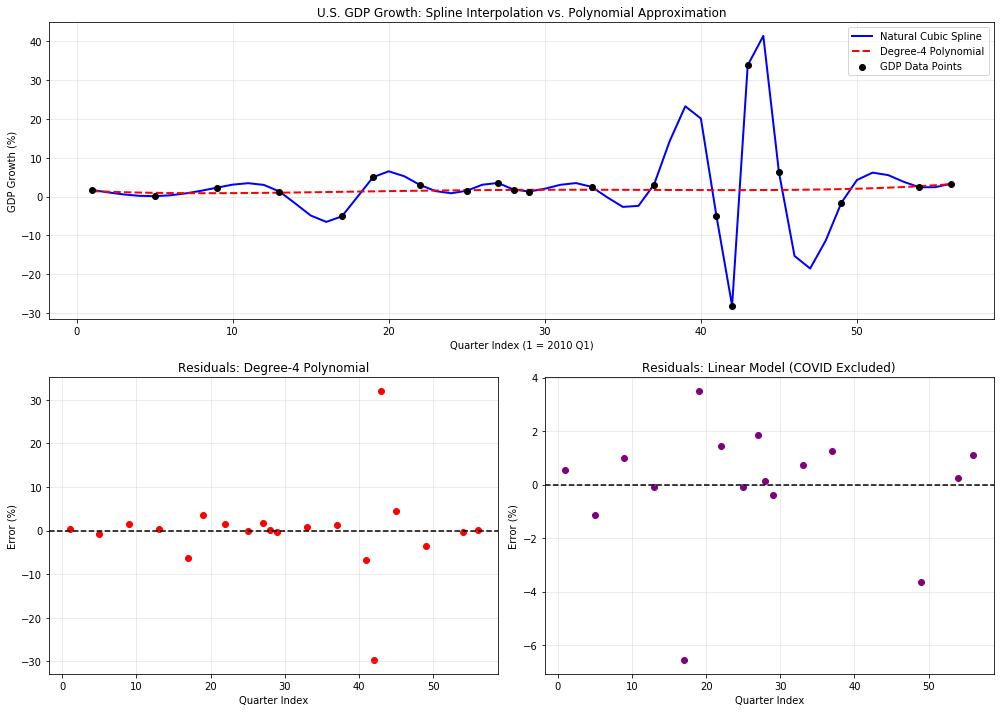

RMSE for Degree-4 Polynomial: 10.1546


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Mapping the "Selected Quarters" to consecutive integer indices (1, 2, 3...)
# Assuming 2010 Q1 is index 1
x_data = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 56])
y_data = np.array([1.7, 0.1, 2.3, 1.3, -5.1, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

# Evaluation grid for plotting the full dataset range (56 quarters total from 2010 Q1 to 2023 Q4)
x_eval = np.arange(1, 57)

def thomas_algorithm(a, b, c, d):
    """Solves a tridiagonal system using the Thomas Algorithm. Runs in O(N) time."""
    n = len(d)
    c_prime = np.zeros(n-1)
    d_prime = np.zeros(n)
    
    # Forward sweep
    c_prime[0] = c[0] / b[0]
    d_prime[0] = d[0] / b[0]
    for i in range(1, n-1):
        c_prime[i] = c[i] / (b[i] - a[i-1] * c_prime[i-1])
    for i in range(1, n):
        d_prime[i] = (d[i] - a[i-1] * d_prime[i-1]) / (b[i] - a[i-1] * c_prime[i-1])
        
    # Back substitution
    x = np.zeros(n)
    x[-1] = d_prime[-1]
    for i in range(n-2, -1, -1):
        x[i] = d_prime[i] - c_prime[i] * x[i+1]
    return x

def compute_natural_spline(x, y):
    """Constructs the natural cubic spline interpolant. Complexity: O(N)"""
    n = len(x)
    h = np.diff(x)
    
    # Tridiagonal system arrays for interior points (size n-2)
    lower = np.zeros(n-3)
    diag = np.zeros(n-2)
    upper = np.zeros(n-3)
    rhs = np.zeros(n-2)
    
    # Building the system to ensure C^0, C^1, and C^2 continuity
    for i in range(1, n-1):
        idx = i - 1
        diag[idx] = (h[i-1] + h[i]) / 3.0
        rhs[idx] = (y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1]
        
        if i > 1:
            lower[idx-1] = h[i-1] / 6.0
        if i < n-2:
            upper[idx] = h[i] / 6.0
            
    # Solve for second derivatives (M) at interior knots
    M_interior = thomas_algorithm(lower, diag, upper, rhs)
    
    # Apply natural boundary conditions: M_0 = 0 and M_n-1 = 0
    M = np.concatenate(([0], M_interior, [0])) 
    return M, h

def evaluate_spline(x_target, x, y, M, h):
    """Evaluates the spline at target points."""
    y_target = np.zeros_like(x_target, dtype=float)
    for j, xi in enumerate(x_target):
        # Find correct interval
        if xi <= x[0]: i = 0
        elif xi >= x[-1]: i = len(x) - 2
        else:
            i = np.searchsorted(x, xi) - 1
            
        dx1 = xi - x[i]
        dx2 = x[i+1] - xi
        
        # Cubic spline equation
        term1 = (M[i] * dx2**3 + M[i+1] * dx1**3) / (6 * h[i])
        term2 = (y[i] * dx2 + y[i+1] * dx1) / h[i]
        term3 = -h[i] * (M[i] * dx2 + M[i+1] * dx1) / 6
        y_target[j] = term1 + term2 + term3
    return y_target

# Calculate and evaluate Spline
M, h = compute_natural_spline(x_data, y_data)
y_spline_eval = evaluate_spline(x_eval, x_data, y_data, M, h)

def fit_polynomial(x, y, degree):
    """Fits a polynomial using Normal Equations. Complexity: O(N * m^2)"""
    # Construct Vandermonde Matrix
    V = np.column_stack([x**i for i in range(degree + 1)])
    
    # Calculate condition number to check for poor scaling
    cond_num = np.linalg.cond(V.T @ V)
    print(f"Condition Number for Degree {degree} Polynomial Matrix: {cond_num:.2e}")
    
    # Normal Equations: V^T * V * c = V^T * y
    A = V.T @ V
    b = V.T @ y
    coeffs = np.linalg.solve(A, b) # linear algebra solver permitted
    return coeffs

def evaluate_polynomial(x, coeffs):
    """Evaluates polynomial given coefficients."""
    return sum(coeffs[i] * x**i for i in range(len(coeffs)))

# 1. Calculate and evaluate Degree-4 Polynomial
poly_coeffs = fit_polynomial(x_data, y_data, degree=4)
y_poly_eval = evaluate_polynomial(x_eval, poly_coeffs)
y_poly_fit = evaluate_polynomial(x_data, poly_coeffs) # For residuals

# 2. Fit Linear Model (Excluding COVID quarters: 2020 Q1 to 2021 Q1)
# Quarters 41 through 45 represent the COVID shock timeframe in our index
covid_mask = (x_data < 41) | (x_data > 45)
x_data_clean = x_data[covid_mask]
y_data_clean = y_data[covid_mask]

lin_coeffs = fit_polynomial(x_data_clean, y_data_clean, degree=1)
y_lin_clean_fit = evaluate_polynomial(x_data_clean, lin_coeffs)

slope = lin_coeffs[1]
print(f"Linear Trend Slope (Excluding COVID): {slope:.4f}")

plt.figure(figsize=(14, 10))

# Plot 1: Spline vs Polynomial
plt.subplot(2, 1, 1)
plt.scatter(x_data, y_data, color='black', label='GDP Data Points', zorder=5)
plt.plot(x_eval, y_spline_eval, color='blue', label='Natural Cubic Spline', linewidth=2)
plt.plot(x_eval, y_poly_eval, color='red', linestyle='--', label='Degree-4 Polynomial', linewidth=2)
plt.title('U.S. GDP Growth: Spline Interpolation vs. Polynomial Approximation')
plt.xlabel('Quarter Index (1 = 2010 Q1)')
plt.ylabel('GDP Growth (%)')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot 2: Residuals for Polynomial
plt.subplot(2, 2, 3)
poly_residuals = y_data - y_poly_fit
plt.scatter(x_data, poly_residuals, color='red')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residuals: Degree-4 Polynomial')
plt.xlabel('Quarter Index')
plt.ylabel('Error (%)')
plt.grid(True, alpha=0.3)

# Plot 3: Residuals for Linear Model (COVID Excluded)
plt.subplot(2, 2, 4)
lin_residuals = y_data_clean - y_lin_clean_fit
plt.scatter(x_data_clean, lin_residuals, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.title('Residuals: Linear Model (COVID Excluded)')
plt.xlabel('Quarter Index')
plt.ylabel('Error (%)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate RMSE for quantitative discussion in Part C
rmse_poly = np.sqrt(np.mean(poly_residuals**2))
print(f"RMSE for Degree-4 Polynomial: {rmse_poly:.4f}")